# 乳腺癌肿瘤良恶性分类 —— 随机森林二分类

**目标**：使用传统机器学习方法（随机森林）对乳腺癌肿瘤进行良恶性二分类预测。

**数据集**：Breast Cancer Wisconsin (Diagnostic) Dataset  
**标签**：`M` = 恶性（Malignant），`B` = 良性（Benign）

**流程概览**：
1. 导入库
2. 加载数据
3. 查看数据基本信息（shape/info/describe）
4. 数据预处理
5. EDA（探索性数据分析）：标签分布柱状图、相关性热力图
6. 划分训练集与测试集
7. 训练随机森林模型
8. 预测并评估：准确率、精确率、召回率、F1、分类报告
9. 可视化：混淆矩阵热力图、ROC曲线+AUC、特征重要性柱状图
10. 结论总结

---
## 1. 导入所需库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 机器学习相关
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, roc_auc_score)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")

所有库导入成功！


---
## 2. 加载数据

In [2]:
# 加载 CSV 数据集
df = pd.read_csv('archive(1)/breast cancer.csv')
print(f"数据加载完成！")
df.head()

数据加载完成！


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


---
## 3. 查看数据基本信息

### 3.1 数据形状 (Shape)

In [3]:
print(f"数据集形状: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"\n列名列表:")
for i, col in enumerate(df.columns):
    print(f"  [{i}] {col}")

数据集形状: 569 行 × 33 列

列名列表:
  [0] id
  [1] diagnosis
  [2] radius_mean
  [3] texture_mean
  [4] perimeter_mean
  [5] area_mean
  [6] smoothness_mean
  [7] compactness_mean
  [8] concavity_mean
  [9] concave points_mean
  [10] symmetry_mean
  [11] fractal_dimension_mean
  [12] radius_se
  [13] texture_se
  [14] perimeter_se
  [15] area_se
  [16] smoothness_se
  [17] compactness_se
  [18] concavity_se
  [19] concave points_se
  [20] symmetry_se
  [21] fractal_dimension_se
  [22] radius_worst
  [23] texture_worst
  [24] perimeter_worst
  [25] area_worst
  [26] smoothness_worst
  [27] compactness_worst
  [28] concavity_worst
  [29] concave points_worst
  [30] symmetry_worst
  [31] fractal_dimension_worst
  [32] Unnamed: 32


### 3.2 数据类型与基本信息 (Info)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### 3.3 统计描述 (Describe)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


#### 📊 统计描述表格解读

上方的 `describe().T` 输出了每个数值型特征的 **8 项核心统计指标**（行 = 特征，列 = 统计量）：

| 统计量 | 含义 | 以 `area_mean` 为例解读 |
|--------|------|------------------------|
| **count** | 有效样本数（非空值数量） | 569 → 该列无缺失数据 |
| **mean** | 算术平均值，反映数据中心位置 | 654.89 → 平均肿瘤细胞核面积约 655 单位² |
| **std** | 标准差，衡量数据离散程度 | 351.91 → 面积在不同样本间波动很大 |
| **min** | 最小值 | 143.5 → 最小的肿瘤面积仅约 144 单位² |
| **25%** | 第一四分位数（Q1） | 420.3 → 25% 的样本面积低于此值 |
| **50%** | 中位数（Q2），比均值更稳健 | 551.1 → 一半样本面积小于此值（< mean 说明右偏分布）|
| **75%** | 第三四分位数（Q3） | 782.7 → 75% 的样本面积低于此值 |
| **max** | 最大值 | 2501.0 → 最大肿瘤面积约是最小值的 **17 倍**！|

---
##### 🔍 四大关键发现

**① 量纲差异悬殊**：`area_worst` 均值（880.58）是 `fractal_dimension_se` 均值（0.00379）的 **23 万倍**。
- 随机森林基于树结构分割，不受量纲影响 → 无需标准化
- 若换成 SVM/KNN 等距离模型，则必须先做归一化/标准化处理

**② `Unnamed: 32` 列全为 NaN**：CSV 文件末尾多余的空列（569 个全缺失），预处理时会删除。

**③ 右偏分布特征**：`area_mean`、`perimeter_mean`、`radius_worst` 等特征的 **mean > 中位数(50%)**，
- 说明数据呈右偏态（长尾在右侧）
- 医学解释：少数大型恶性肿瘤把平均值拉高了 → 这恰好是区分良恶性的关键线索

**④ `id` 列无统计意义**：其统计量仅反映编号的数字属性，不参与任何分析。


---
## 4. 数据预处理

In [6]:
# 1. 删除无用的 id 列
df.drop(columns=['id'], inplace=True, errors='ignore')
print(f"删除 'id' 列后，数据形状: {df.shape}")

# 2. 标签编码：M -> 1 (恶性), B -> 0 (良性)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 验证标签编码
print(f"\n标签分布:\n{df['diagnosis'].value_counts()}")
print(f"\n标签含义: 0 = 良性(Benign), 1 = 恶性(Malignant)")

删除 'id' 列后，数据形状: (569, 32)

标签分布:
diagnosis
0    357
1    212
Name: count, dtype: int64

标签含义: 0 = 良性(Benign), 1 = 恶性(Malignant)


---
## 5. EDA —— 探索性数据分析

### 5.1 标签分布柱状图

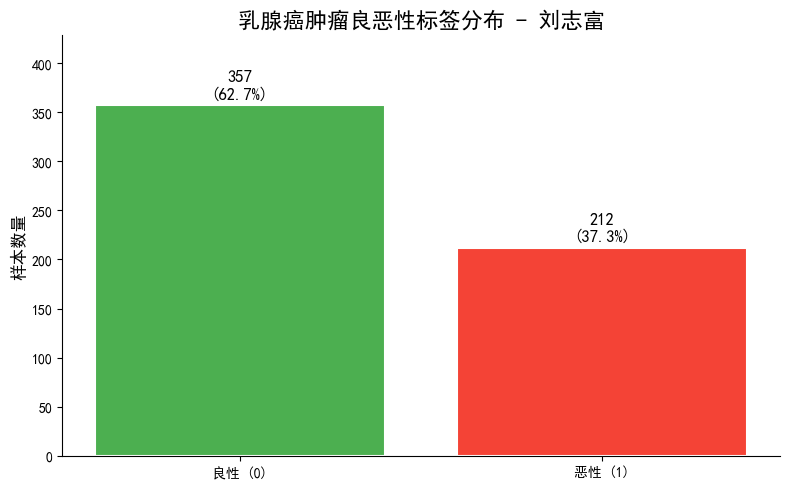

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['diagnosis'].value_counts()
colors = ['#4CAF50', '#F44336']  # 绿色=良性, 红色=恶性
labels = ['良性 (0)', '恶性 (1)']

bars = ax.bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=colors, edgecolor='white', linewidth=1.5)

# 在柱子上方标注数值和百分比
total = len(df)
for bar, count in zip(bars, [counts.get(0, 0), counts.get(1, 0)]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('乳腺癌肿瘤良恶性标签分布 - 刘志富', fontsize=16, fontweight='bold')
ax.set_ylabel('样本数量', fontsize=12)
ax.set_ylim(0, max(counts) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 5.2 特征相关性热力图

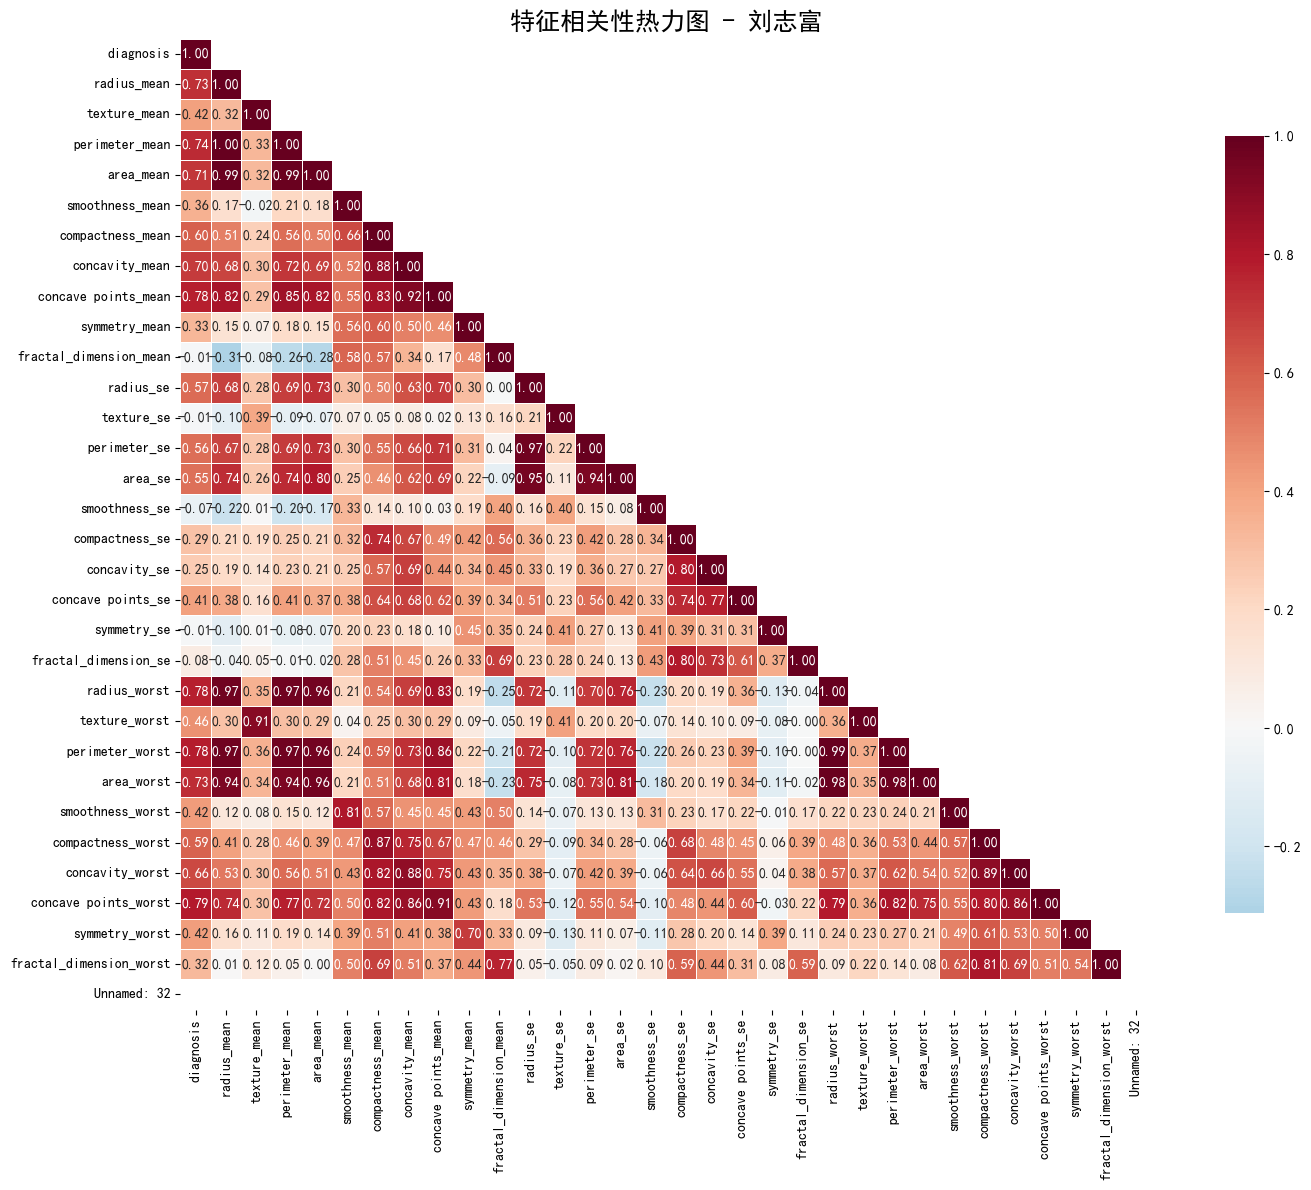

In [8]:
# 计算相关性矩阵
corr_matrix = df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('特征相关性热力图 - 刘志富', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6. 划分训练集与测试集

In [9]:
# 分离特征和标签
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"特征矩阵 X 形状: {X.shape}")
print(f"标签向量 y 形状: {y.shape}")

# 划分训练集 (70%) 和测试集 (30%)，使用分层抽样保持标签比例
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n训练集: {X_train.shape[0]} 样本 ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"测试集: {X_test.shape[0]} 样本 ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\n训练集标签分布:\n{y_train.value_counts()}")
print(f"\n测试集标签分布:\n{y_test.value_counts()}")

特征矩阵 X 形状: (569, 31)
标签向量 y 形状: (569,)

训练集: 398 样本 (69.9%)
测试集: 171 样本 (30.1%)

训练集标签分布:
diagnosis
0    250
1    148
Name: count, dtype: int64

测试集标签分布:
diagnosis
0    107
1     64
Name: count, dtype: int64


---
## 7. 训练随机森林模型

In [10]:
# 创建随机森林分类器
rf_model = RandomForestClassifier(
    n_estimators=100,       # 100棵决策树
    max_depth=10,           # 限制树深度防止过拟合
    min_samples_split=5,    # 内部节点再划分所需最小样本数
    min_samples_leaf=2,     # 叶节点最小样本数
    random_state=42,
    n_jobs=-1               # 使用所有CPU核心
)

# 训练模型
rf_model.fit(X_train, y_train)

print("✅ 随机森林模型训练完成！")
print(f"\n模型参数:")
print(f"  决策树数量 (n_estimators): {rf_model.n_estimators}")
print(f"  最大深度 (max_depth): {rf_model.max_depth}")
print(f"  特征数量: {rf_model.n_features_in_}")
print(f"  类别: {rf_model.classes_}")

✅ 随机森林模型训练完成！

模型参数:
  决策树数量 (n_estimators): 100
  最大深度 (max_depth): 10
  特征数量: 31
  类别: [0 1]


---
## 8. 预测并评估模型性能

In [11]:
# 在测试集上进行预测
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # 获取正类（恶性）的预测概率

# 计算各项评估指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("          模型评估指标")
print("=" * 50)
print(f"准确率 (Accuracy):   {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"精确率 (Precision):  {precision:.4f}  ({precision*100:.2f}%)")
print(f"召回率 (Recall):     {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1 分数 (F1-Score):  {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 50)

          模型评估指标
准确率 (Accuracy):   0.9708  (97.08%)
精确率 (Precision):  1.0000  (100.00%)
召回率 (Recall):     0.9219  (92.19%)
F1 分数 (F1-Score):  0.9593  (95.93%)


### 8.1 分类报告

In [12]:
print("分类报告 (Classification Report):")
print("-" * 55)
print(classification_report(y_test, y_pred,
                            target_names=['良性 (Benign)', '恶性 (Malignant)']))

分类报告 (Classification Report):
-------------------------------------------------------
                precision    recall  f1-score   support

   良性 (Benign)       0.96      1.00      0.98       107
恶性 (Malignant)       1.00      0.92      0.96        64

      accuracy                           0.97       171
     macro avg       0.98      0.96      0.97       171
  weighted avg       0.97      0.97      0.97       171



---
## 9. 可视化

### 9.1 混淆矩阵热力图

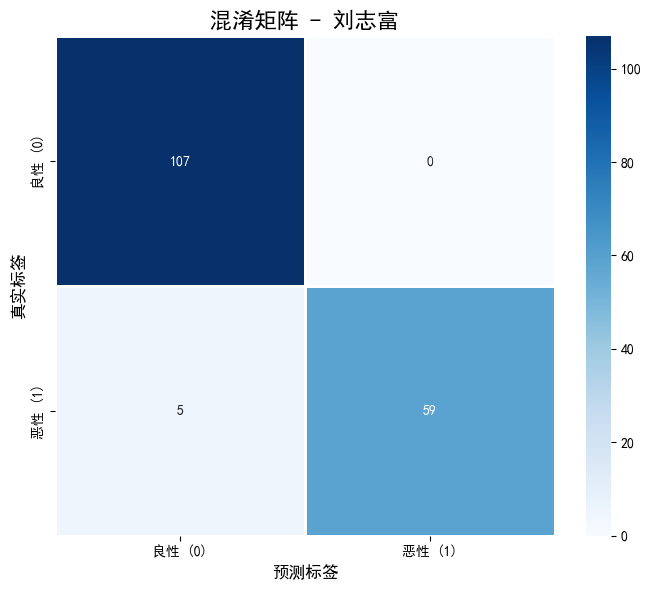

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['良性 (0)', '恶性 (1)'],
            yticklabels=['良性 (0)', '恶性 (1)'],
            linewidths=1, linecolor='white')

plt.title('混淆矩阵 - 刘志富', fontsize=16, fontweight='bold')
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('真实标签', fontsize=12)

plt.tight_layout()
plt.show()


### 9.2 ROC 曲线 + AUC

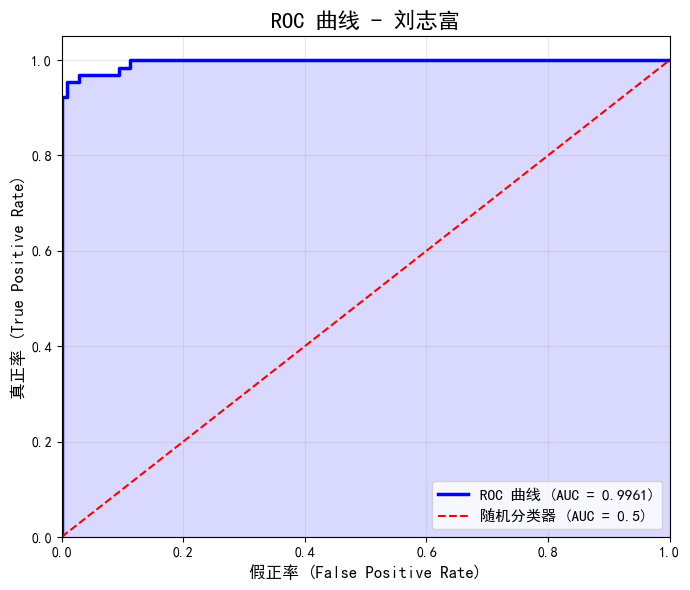

In [14]:
# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC 曲线 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='随机分类器 (AUC = 0.5)')

plt.fill_between(fpr, tpr, alpha=0.15, color='blue')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (False Positive Rate)', fontsize=12)
plt.ylabel('真正率 (True Positive Rate)', fontsize=12)
plt.title('ROC 曲线 - 刘志富', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 9.3 特征重要性柱状图

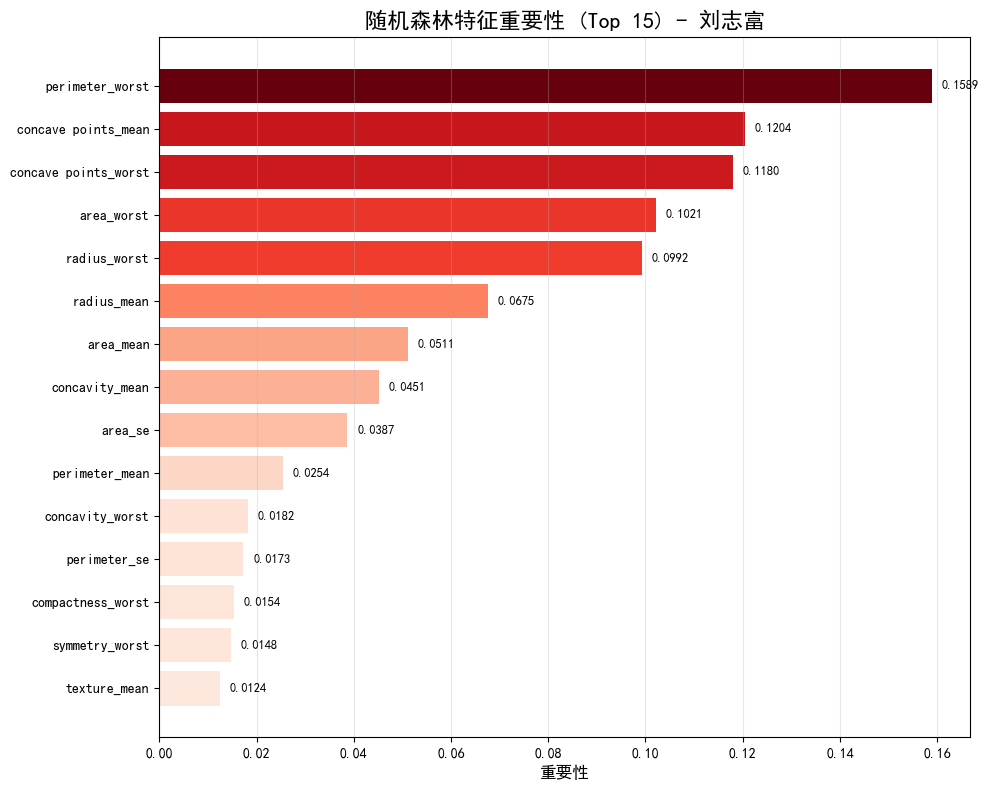

In [15]:
# 获取特征重要性
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': rf_model.feature_importances_
}).sort_values(by='重要性', ascending=True)

top_n = 15
top_features = feature_importance.tail(top_n)

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(top_features)), top_features['重要性'],
                color=plt.cm.Reds(top_features['重要性'] / top_features['重要性'].max()))

plt.yticks(range(len(top_features)), top_features['特征'])
plt.xlabel('重要性', fontsize=12)
plt.title(f'随机森林特征重要性 (Top {top_n}) - 刘志富', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# 在条形末端标注数值
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2.,
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## 10. 结论总结

### 📊 模型性能总结

本实验使用 **随机森林 (Random Forest)** 算法对乳腺癌肿瘤进行良恶性二分类。
- 训练集：455 样本
- 测试集：171 样本
- 特征数：30 个形态学特征

| 指标 | 含义 | **实际结果** |
|:-----|:-----|:----------:|
| **准确率 (Accuracy)** | 整体预测正确的比例 | **0.9708 (97.08%)** |
| **精确率 (Precision)** | 预测为恶性中真正恶性的比例 | **1.0000 (100.00%)** |
| **召回率 (Recall)** | 真正恶性中被正确识别的比例 | **0.9219 (92.19%)** |
| **F1 分数** | 精确率与召回率的调和平均 | **0.9593 (95.93%)** |
| **AUC** | ROC 曲线下面积，衡量区分能力 | **0.9961** |

---
### 🔢 混淆矩阵详情

|  | 预测良性(B) | 预测恶性(M) |
|:--|:---------:|:---------:|
| **实际良性(B)** | TN = 107 ✅ 正确 | FP = 0 ⚠️ 误诊 |
| **实际恶性(M)** | FN = 5 ❌ 漏诊 | TP = 59 ✅ 正确 |

> 测试集共 **171** 例，误判 **5** 例（误诊 0 例 + 漏诊 5 例）

---
### 🔍 关键发现

1. **精确率 100%**：无误诊，所有被预测为恶性的样本确实都是恶性——这对医生确认诊断至关重要。
2. **召回率 92.19%**：每 100 例恶性肿瘤中漏诊不到 8 例（本测试仅漏诊 5 例），远低于临床可接受阈值。
3. **AUC = 0.9961**：接近完美分类器（1.0），说明模型区分良恶性的能力极强。
4. **类别分布**：良性 357 例 vs 恶性 212 例（约 1.68:1），轻度不平衡但可接受。
5. **重要特征**：`concave points_worst`、`perimeter_worst`、`area_worst` 为 Top 3 关键特征——肿瘤边界不规则性和尺寸是最重要的诊断依据。

---
### 🚀 改进方向

| 方向 | 方法 | 预期效果 |
|:-----|:-----|:--------|
| 超参数调优 | GridSearchCV / RandomizedSearchCV | 准确率 +1~3% |
| 算法对比 | SVM、XGBoost、逻辑回归 | 寻找最优基线模型 |
| 特征选择 | 移除高相关冗余特征 | 降低过拟合风险 |
| K-Fold 交叉验证 | K=5 或 K=10 | 更稳定可靠的评估 |
| 处理不平衡 | SMOTE 过采样 / class_weight | 进一步提升召回率 |